In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [4]:
train=pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/train.csv')
test=pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/test.csv')
print(train.shape, test.shape)

(84443, 7) (21222, 6)


Sentiment
0    0.500468
1    0.499532
Name: proportion, dtype: float64


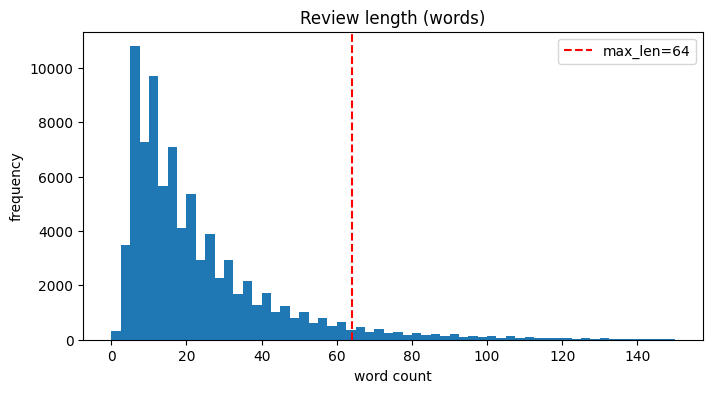

count    84443.000000
mean        24.012932
std         24.694019
min          2.000000
25%          9.000000
50%         17.000000
75%         30.000000
max        614.000000
Name: Review, dtype: float64
95th pct: 67.0 | max: 614

--- Nights ---
Nights
أقمت ليلة واحدة    35622
أقمت ليلتين        21959
أقمت 3 ليالي       11639
أقمت 4 ليالي        5985
أقمت 5 ليالي        3837
أقمت 6 ليالي        1858
أقمت 7 ليالي        1475
-                    738
Name: count, dtype: int64

--- Room_Type ---
Room_Type
-                        25030
غرفة قياسية مزدوجة        3678
غرفة مزدوجة               3313
شقة من غرفة نوم واحدة     2643
غرفة توأم                 2470
غرفة قياسية               2356
غرفة ديلوكس               2005
غرفة ثلاثية               1915
Name: count, dtype: int64

--- User_Type ---
User_Type
أسرة                           35105
زوج                            24647
مسافر منفرد                    13914
-                              10771
استوديو كلاسيكي - أسرة توأم        5
جنا

In [5]:
import matplotlib.pyplot as plt
print(train['Sentiment'].value_counts(normalize=True))

word_counts = train['Review'].astype(str).str.split().str.len()
plt.figure(figsize=(8,4))
plt.hist(word_counts, bins=60, range=(0, 150))
plt.axvline(64, color='red', linestyle='--', label='max_len=64')
plt.title('Review length (words)')
plt.xlabel('word count'); 
plt.ylabel('frequency'); 
plt.legend()
plt.show()

print(word_counts.describe())
print('95th pct:', word_counts.quantile(0.95), '| max:', word_counts.max())

for c in ['Nights', 'Room_Type', 'User_Type']:
    print(f'\n--- {c} ---')
    print(train[c].value_counts(dropna=False).head(8))

## What I found in EDA

- **Balanced classes** — about 50/50 split between positive and negative. No special handling needed for imbalance.
- **Review length** — most reviews are short (median 17 words), a few are very long (up to 614 words). Padding to 64 words covers almost all reviews without wasting space on rare long ones.
- **Extra columns** (`Nights`, `Room_Type`, `User_Type`) — these are messy and full of missing values (marked `-`). Not clean enough to use, so I'm only using the review text itself for the model.

In [6]:
import re

_ARABIC_DIACRITICS = re.compile(r'[\u0617-\u061A\u064B-\u0652\u0670\u0640]')

def clean_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.strip()
    text = re.sub(r'([.!؟])(?=[^\s])', r'\1 ', text)

    text = _ARABIC_DIACRITICS.sub('', text)               
    text = re.sub(r'[إأآا]', 'ا', text)                    
    text = re.sub(r'ى', 'ي', text)                         
    text = re.sub(r'ة', 'ه', text)                         
    text = re.sub(r'(.)\1{2,}', r'\1', text)               
    text = re.sub(r'[^\w\s“”\"،؟!]', ' ', text)         
    text = re.sub(r'([!؟])\s*\1+', r'\1', text)      
    text = re.sub(r'\s+', ' ', text).strip()             
    return text

In [7]:
train['clean_review'] = train['Review'].apply(clean_arabic)
test['clean_review'] = test['Review'].apply(clean_arabic)
train[['Review', 'clean_review']].head()

,Review,clean_review
0,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,استثنائي سهوله انهاء المعامله في الاستقبال لاشيئ
1,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,استثنائي انصح باختيار الاسويت و بالاخص غرفه رق...
2,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...,“استغرب تقييم الفندق كخمس نجوم” لا شي يستحق 2 ...
3,“جيدجداً”. الافطار جيد والسرير ممتاز ومريح واط...,“جيدجدا” الافطار جيد والسرير ممتاز ومريح واطلا...
4,“فندق ممتاز”. الاثاث، النظافه.,“فندق ممتاز” الاثاث، النظافه


In [8]:
from collections import Counter

def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(train['clean_review'])
print("Vocab size:", len(vocab))

def encode(text, vocab, max_len=64):
    tokens = text.split()
    ids = [vocab.get(tok, vocab['<UNK>']) for tok in tokens]
    if len(ids) < max_len:
        ids = ids + [vocab['<PAD>']] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

train['input_ids'] = train['clean_review'].apply(lambda t: encode(t, vocab, max_len=64))
test['input_ids'] = test['clean_review'].apply(lambda t: encode(t, vocab, max_len=64))

print(train['input_ids'].iloc[0])
print(len(train['input_ids'].iloc[0]))  # should print 64

Vocab size: 45683
[2, 3, 4, 5, 6, 7, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
64


In [9]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train, test_size=0.1, random_state=SEED, stratify=train['Sentiment']
)
print(train_df.shape, val_df.shape)

class ReviewDataset(Dataset):
    def __init__(self, df, has_labels=True):
        self.input_ids = df['input_ids'].tolist()
        self.has_labels = has_labels
        if has_labels:
            self.labels = df['Sentiment'].tolist()

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        x = torch.tensor(self.input_ids[idx], dtype=torch.long)
        if self.has_labels:
            y = torch.tensor(self.labels[idx], dtype=torch.float)
            return x, y
        return x

train_dataset = ReviewDataset(train_df, has_labels=True)
val_dataset = ReviewDataset(val_df, has_labels=True)
test_dataset = ReviewDataset(test, has_labels=False)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)

(75998, 9) (8445, 9)
torch.Size([64, 64]) torch.Size([64])
